# 03 — Association: does within-country populism track corruption?

**Task 3 only.** This notebook establishes the *association* — it does not probe causal direction
(that is Task 4's lead-lag / Granger work). It answers a *within-country* question: when a country's
governing-party populism rises, does its political corruption rise too? All statistical logic lives in
`src/association/`; here we only load data, call those functions, render results, and interpret.

The framing matters. A naive pooled correlation (which the EDA found at +0.12) mixes two things:
*populist-governed countries tend to be more corrupt* (a **between**-country fact) and *a country
becomes more corrupt as its populism rises* (a **within**-country claim). Country fixed effects
isolate the second — the more defensible question — by removing every fixed difference between
countries (history, region, culture).

> **How to read this notebook.** Each uncommon method (fixed effects, clustered SEs, within-R²,
> Hausman, GroupKFold, SHAP) gets a short plain-language note before its output: *what it is / why we
> use it / what it can and can't tell us.* No statistics background is assumed.

In [1]:
import sys
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import polars as pl

sys.path.insert(0, str(Path.cwd().parent / "src"))
import association as A

PANEL_PATH = Path("../data/processed/panel_populism_corruption.parquet")
panel = pl.read_parquet(PANEL_PATH).to_pandas()
print("panel:", panel.shape, "| countries:", panel["country_id"].nunique(),
      "| years:", panel["year"].min(), "-", panel["year"].max())
panel[["country_id", "year", "country_name", "populism_governing", "v2x_corr"]].head()

panel: (3965, 31) | countries: 96 | years: 1970 - 2019


,country_id,year,country_name,populism_governing,v2x_corr
0,3,1970,Mexico,0.199,0.82
1,3,1971,Mexico,0.199,0.82
2,3,1972,Mexico,0.199,0.82
3,3,1973,Mexico,0.196,0.82
4,3,1974,Mexico,0.196,0.82


## Section 0 — Setup & the estimation samples

The static models **M1–M3 share one stability sample**: the rows non-missing on the M1–M3 variables
(populism, log GDP, polyarchy), so a coefficient that moves across M1→M3 reflects an added control, not a
shifting sample. **M4 is different** — it adds last year's corruption (a separate, *dynamic* estimand), so
it is fit on its **own** complete-case sample rather than forcing M1–M3 to drop each country's first year
for a lag they do not use. We report both sample sizes below.

In [2]:
stability = panel.dropna(subset=A.TWFE_STABILITY_VARS)
print(f"full panel rows:        {len(panel)}")
print(f"M1-M3 stability sample: {len(stability)} rows, {stability['country_id'].nunique()} countries "
      f"(complete on populism, log GDP, polyarchy)")
m4 = panel.dropna(subset=A.TWFE_M4_VARS)
print(f"M4 sample (adds lag):   {len(m4)} rows, {m4['country_id'].nunique()} countries (its own complete-case set)")
dropped = panel.loc[~panel.index.isin(stability.index)]
print(f"  dropped from M1-M3: {len(dropped)} rows; mean log GDP kept {stability['log_gdppc'].mean():.2f} "
      f"vs dropped {dropped['log_gdppc'].mean():.2f}")

full panel rows:        3965
M1-M3 stability sample: 3940 rows, 95 countries (complete on populism, log GDP, polyarchy)
M4 sample (adds lag):   3845 rows, 95 countries (its own complete-case set)
  dropped from M1-M3: 25 rows; mean log GDP kept 2.70 vs dropped nan


## Section 1 — How much *within-country* variation is there?

**What this is.** Fixed effects learns only from *within*-country movement — how a country deviates
from its own long-run average. This table splits the variance of `populism_governing` into a
between-country part (how countries differ) and a within-country part (how each country moves over
time).

**Why we look first.** If almost all the variance were between countries, FE would have little signal
and any null result would be unsurprising. This calibrates expectations before we fit.

In [3]:
vb = A.within_between_variance(panel, "populism_governing")
print(f"within-country share of populism variance:  {vb['within_share']:.1%}")
print(f"between-country share:                       {vb['between_share']:.1%}")
print(f"(n = {vb['n_obs']} country-years, {vb['n_countries']} countries)")

within-country share of populism variance:  44.3%
between-country share:                       55.7%
(n = 3965 country-years, 96 countries)


About 44% of the variance in governing-party populism is *within* countries — so populism is not
frozen per country, and a weak within-country result is not merely "nothing changed". **But a caveat
(audit #11):** because the predictor is forward-filled and only updates around elections, those
country-years represent far fewer *distinct* government-populism transitions than the ~3,900 rows
suggest. So this variance share sets expectations, but it does **not** prove the design has enough
independent treatment variation to call a small estimate "definitively zero". Power is genuinely
limited — we treat near-zero estimates as *imprecise*, not as proof of no effect.

## Section 2 — Persistence baseline (how sticky is corruption?)

In [4]:
pb = A.fit_persistence_baseline(panel)
print(f"persistence baseline:  within-R2 = {pb['within_r2']:.3f},  "
      f"lag coefficient = {pb['lag_coef']:.3f}")
print(f"(n = {pb['n_obs']} country-years, {pb['n_countries']} countries)")

persistence baseline:  within-R2 = 0.886,  lag coefficient = 0.938
(n = 3869 country-years, 96 countries)


Last year's corruption explains the overwhelming majority of this year's (within-R² ≈ 0.89, lag ≈ 0.94):
corruption is extremely sticky. **This documents outcome persistence — it is not a performance bar the
static model must "beat" (audit #8).** The persistence model is dynamic (includes the lag), entity-only,
and answers a prediction question; the static M1-M3 models estimate a contemporaneous association. Their
within-R² values are not comparable as a contest. We keep this only to motivate why a single-year
predictor has little leftover variation to explain.

## Section 3 — Two-way fixed-effects grid (M1–M3)

**What "country + year fixed effects" means.** Before estimating, we subtract each country's own
average over time (removing "Denmark is always clean") *and* each year's global average (removing "the
2000s were cleaner everywhere"). What's left is within-country, within-year variation. The regression
asks whether residual populism moves with residual corruption.

**What "clustered standard errors" means.** Observations from the same country across years aren't
independent — they share institutions and history. Clustering by country widens the confidence
intervals to account for this. We report the number of clusters (countries); cluster-robust inference
wants roughly 40+.

The three models add one control at a time (all share the same estimand — the *level* association):
**M1** populism + country FE + year FE; **M2** + log GDP per capita; **M3** + polyarchy
(electoral-democracy). If the populism coefficient barely moves as controls are added, it isn't an
artefact of those omitted variables.

In [5]:
grid = A.fit_twfe_grid(panel)
print(f"M1-M3 stability sample: {grid.n_obs} country-years, {grid.n_countries} countries")
print(f"M4 sample (separate):   {grid.m4_n_obs} country-years, {grid.m4_n_countries} countries\n")

def coef_row(name, m, term="populism_governing"):
    ci = m.conf_int().loc[term]
    return {"model": name, "populism_coef": round(m.params[term],4),
            "ci_low": round(ci["lower"],4), "ci_high": round(ci["upper"],4),
            "p_value": round(m.pvalues[term],4), "sig_5pct": (ci["lower"]>0 or ci["upper"]<0),
            "within_R2": round(m.rsquared_within,3)}
pd.DataFrame([coef_row(n, grid.models[n]) for n in ["M1","M2","M3","M4"]])

M1-M3 stability sample: 3940 country-years, 95 countries
M4 sample (separate):   3845 country-years, 95 countries



,model,populism_coef,ci_low,ci_high,p_value,sig_5pct,within_R2
0,M1,-0.0677,-0.1394,0.0040,0.0644,False,0.010
1,M2,-0.0715,-0.1408,-0.0023,0.0428,True,-0.059
2,M3,-0.0638,-0.1234,-0.0042,0.0358,True,-0.196
3,M4,-0.0033,-0.0163,0.0097,0.6148,False,0.885


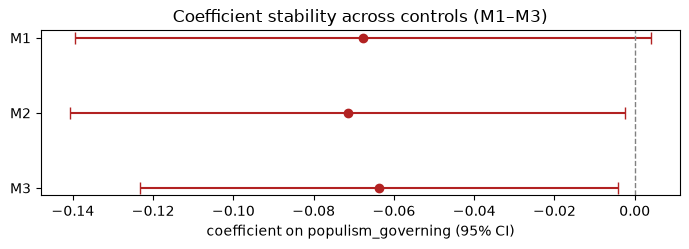

In [6]:
ax = A.coefficient_stability_plot(grid)
plt.tight_layout(); plt.show()

**Reading M1–M3 (corrected).** The populism coefficient is **consistently negative** (about −0.06 to
−0.07) and barely moves as GDP and democracy controls are added. Its statistical significance is
**specification-dependent**: M1 (no controls) has an interval that includes zero (p≈0.06), but **M2 and
M3 — the controlled static models — are significant at 5%** (p≈0.043 and 0.036; intervals exclude zero).

So this is **not** "no relationship". The honest statement: *within countries, governing-party populism
is associated with slightly **lower** corruption, significantly so once GDP and democracy are held
fixed.* This is the **opposite sign** to the +0.14 pooled correlation — the next cell shows why.

(The within-R² values are tiny/negative because populism + controls explain almost none of the
year-to-year *movement* in corruption; that is about predictive fit, not about the coefficient's sign.)

### Where the +0.14 correlation actually lives (between vs within)

The naive correlation is positive; the within-country models are negative. To see why, we estimate the
*same* one-predictor relationship four ways (reproducible via `fit_between_within_comparison`, audit #6):

In [7]:
bw = A.fit_between_within_comparison(panel)
pd.DataFrame([
    {"estimator": n, "populism_coef": round(float(m.params["populism_governing"]),4),
     "ci_low": round(float(m.conf_int().loc["populism_governing","lower"]),3),
     "ci_high": round(float(m.conf_int().loc["populism_governing","upper"]),3)}
    for n, m in bw.items()
])

,estimator,populism_coef,ci_low,ci_high
0,Pooled OLS (between+within),0.1453,-0.024,0.315
1,Between-country,0.2255,-0.065,0.516
2,Entity FE (within),-0.0653,-0.143,0.012
3,Two-way FE (within+year),-0.0676,-0.139,0.004


**Reading it.** The *point estimates* show the sign reversal: positive across countries (pooled +0.15,
between +0.23), negative within (−0.07). **But with dependence-adjusted SEs (pooled clustered by country,
between robust) none of these four single-predictor estimates is statistically significant** (pooled
p≈0.09, between p≈0.13, within p≈0.07–0.10). So the honest statement is: the point estimates **flip sign**
from between to within, but the cross-country association is **imprecise** once panel dependence is handled
— we should not call it "clearly positive" or "entirely between." A *significant* within-country estimate
appears only in the controlled models (M2/M3, which add GDP and democracy).

### Is the effect *substantively* large? (audit #12)

A coefficient of −0.06 is per a full 0→1 swing in populism, which never happens. We translate it into
realistic within-country moves:

In [8]:
import numpy as np
s = panel.dropna(subset=["populism_governing"]).copy()
within_sd = s.groupby("country_id")["populism_governing"].transform(lambda x: x - x.mean()).std()
iqr = s["populism_governing"].quantile(.75) - s["populism_governing"].quantile(.25)
elec_chg = (panel.sort_values(["country_id","year"]).query("is_election_year")
            .groupby("country_id")["populism_governing"].diff().abs().median())
coef = grid.models["M3"].params["populism_governing"]
overall_corr_sd = panel["v2x_corr"].std()
within_corr_sd = (panel.dropna(subset=["v2x_corr"]).groupby("country_id")["v2x_corr"]
                  .transform(lambda x: x - x.mean()).std())
print(f"within-country SD of populism = {within_sd:.3f} | IQR = {iqr:.3f} | median election change = {elec_chg:.3f}")
print(f"M3 coef {coef:+.4f} x a within-SD move -> {coef*within_sd:+.4f} on v2x_corr, which is:")
print(f"   {coef*within_sd/overall_corr_sd*100:+.1f}% of the OVERALL corruption SD ({overall_corr_sd:.3f})")
print(f"   {coef*within_sd/within_corr_sd*100:+.1f}% of the WITHIN-country corruption SD ({within_corr_sd:.3f}) <- the apt denominator for a within estimator")
print(f"a typical election-to-election change -> {coef*elec_chg:+.4f} on v2x_corr (negligible)")

within-country SD of populism = 0.159 | IQR = 0.351 | median election change = 0.042
M3 coef -0.0638 x a within-SD move -> -0.0101 on v2x_corr, which is:
   -3.4% of the OVERALL corruption SD (0.296)
   -9.7% of the WITHIN-country corruption SD (0.104) <- the apt denominator for a within estimator
a typical election-to-election change -> -0.0027 on v2x_corr (negligible)


So even where significant, the association is **modest** — but the denominator matters. A one-within-SD
move in governing populism shifts predicted corruption by about **3% of the *overall* corruption SD**, or
about **10% of the *within-country* corruption SD** (the more apt yardstick for a within estimator, since
that is the variation the model actually uses). A typical election-to-election change is negligible. Either
way it is small; we just name which SD we divide by.

## Section 4 — M4: the short-run (dynamic) specification

M4 adds **last year's corruption** as a predictor. It is deliberately *not* on the stability plot:
adding the lagged outcome changes the question. The populism coefficient now measures only the
short-run movement *not already explained by last year's level* — and since corruption is so sticky,
that leftover is tiny, so the coefficient mechanically shrinks toward zero. A smaller M4 coefficient
is expected, not evidence of fragility. (Including a lagged outcome alongside country FE also induces
a small downward "Nickell" bias, negligible with ~50 years per country — we flag, don't correct it.)

In [9]:
m4 = grid.models["M4"]
ci = m4.conf_int().loc["populism_governing"]
print(f"M4 populism coef = {m4.params['populism_governing']:+.4f} "
      f"[{ci['lower']:+.4f}, {ci['upper']:+.4f}]   (vs ~-0.06 in M1-M3)")
print(f"M4 within-R2 = {m4.rsquared_within:.3f}  (dominated by the lag, as expected)")

M4 populism coef = -0.0033 [-0.0163, +0.0097]   (vs ~-0.06 in M1-M3)
M4 within-R2 = 0.885  (dominated by the lag, as expected)


## Section 5 — Fixed vs random effects: the Hausman diagnostic

**What this is.** Fixed effects (FE) and random effects (RE) are two ways to handle country-specific
baselines. FE estimates each baseline freely, removing any bias from country-level confounders. RE
instead *assumes* those baselines are uncorrelated with the predictors — a stronger, often
unrealistic assumption. We chose FE on theoretical grounds: it would be surprising if a country's
inherent corruption level were unrelated to how populist its parties tend to be.

**What the test does and doesn't tell us.** Hausman formally checks whether RE's assumption holds. We
report it as a **diagnostic** — the result does not change our model choice (FE is right for the
research question regardless), but a strongly significant statistic confirms RE would have been
biased. The test can be numerically unstable here; if the covariance difference is not
positive-definite we flag it and read the statistic with caution.

In [10]:
h = A.hausman_fe_re(panel)
print(f"Hausman statistic = {h['stat']:.2f} (dof {h['dof']});  covariance positive-definite: {h['cov_pos_def']}")
if h["reliable"]:
    print(f"p = {h['pvalue']:.4g} -> a valid chi-square test")
else:
    print("p-value is NOT reported as valid: the covariance difference is not positive-definite,")
    print("so the statistic has no dependable chi-square interpretation (audit #7).")

Hausman statistic = 45.46 (dof 3);  covariance positive-definite: False
p-value is NOT reported as valid: the covariance difference is not positive-definite,
so the statistic has no dependable chi-square interpretation (audit #7).


**Reading it (corrected).** The covariance difference here is **not positive-definite**, so the Hausman
statistic does **not** have a dependable chi-square interpretation and we do **not** report it as a formal
rejection of random effects (audit #7). That is fine: our choice of fixed effects does not rest on this
test — it follows directly from the research question (we want the *within*-country comparison and would
use FE regardless). The diagnostic is shown for completeness only.

## Section 6 — Interaction: does populism bite harder in weaker democracies?

We add a `populism × polyarchy` interaction to M2. **Plain question:** does a populist government
track more corruption in a weak democracy than in a strong one? The interaction coefficient is the
*change in the populism slope* per unit of the electoral-democracy index.

In [11]:
it = A.fit_twfe_interaction(panel)
term = "populism_governing:v2x_polyarchy"
ci = it.conf_int().loc[term]
print(f"interaction {term} = {it.params[term]:+.4f}  [{ci['lower']:+.4f}, {ci['upper']:+.4f}]  "
      f"p={it.pvalues[term]:.4f}  (significant)\n")
print("Marginal effect of populism on corruption at low / median / high electoral democracy:")
A.interaction_marginal_effects(panel)

interaction populism_governing:v2x_polyarchy = +0.2568  [+0.0569, +0.4568]  p=0.0118  (significant)

Marginal effect of populism on corruption at low / median / high electoral democracy:


,polyarchy_quantile,polyarchy_value,marginal_effect,ci_low,ci_high,excludes_zero
0,p10,0.136,-0.1635,-0.2815,-0.0456,True
1,p50,0.479,-0.0755,-0.1392,-0.0118,True
2,p90,0.876,0.0265,-0.0399,0.0929,False


**Reading it (this matters).** The interaction is **significant** (CI excludes zero), so the
populism–corruption slope is **not uniform — it changes with the democracy level**. These are
*model-implied marginal slopes* at low / median / high polyarchy (not separate regressions on subsets of
countries):

- **Low polyarchy (10th pct):** slope = **−0.16, significant**.
- **Median polyarchy:** **−0.08, significant**.
- **High polyarchy (90th pct):** **≈ +0.03, not significant**.

So the model implies the negative association is steepest at low democracy levels and ≈ zero at high ones.
A flat "no relationship" claim is wrong. *Caution:* this is a linear-interaction extrapolation and is
associational — the negative slope at low democracy could also reflect how corruption is coded in
consolidated populist regimes.

## Section 7 — XGBoost: a cross-national predictive check

**What GroupKFold is and why we use it.** Our question is whether a populism–corruption relationship
holds *across countries*, not whether we can forecast the future — so we validate by holding out
*entire countries* (GroupKFold, folds stratified by world region so each spans the globe) and testing
whether the model generalises to countries it never trained on. Out-of-fold (OOF) R² is the honest
out-of-sample score.

**Why raw features (no demeaning).** Demeaning each country by its own mean and then holding that
country out would leak the test country's mean into its features — so we use raw features. The
trade-off: XGBoost can exploit *between*-country signal ("richer, more democratic countries are
cleaner") that fixed effects deliberately remove, so its R² will look better than the FE within-R²
**by design** — not because it answers our within-country question better.

**The honest headline is the SHAP rank of populism,** not the R² race. SHAP measures how much each
feature moves the model's predictions; it describes the fitted XGBoost only and is *not* statistical
significance.

In [12]:
xgb = A.fit_xgboost_cv(panel)
print(f"XGBoost  OOF-R2 = {xgb.oof_r2_mean:.3f} +/- {xgb.oof_r2_std:.3f}")
print(f"Linear   OOF-R2 = {xgb.linear_oof_r2:.3f}  (same folds, apples-to-apples)")
print("\nSHAP mean|importance| (out-of-fold):")
for k, v in sorted(xgb.feature_importances.items(), key=lambda kv: -kv[1]):
    print(f"  {k:22s} {v:.4f}")

bench = A.benchmark_table(pb["within_r2"], grid.models["M2"].rsquared_within, xgb)
bench.round(3)

XGBoost  OOF-R2 = 0.453 +/- 0.052
Linear   OOF-R2 = 0.380  (same folds, apples-to-apples)

SHAP mean|importance| (out-of-fold):
  v2x_polyarchy          0.1561
  log_gdppc              0.0598
  populism_governing     0.0363


,model,metric_type,r2
0,Persistence baseline (corr ~ lag + country FE),within-R²,0.886
1,TWFE M2 (populism + log GDP),within-R²,-0.059
2,"Linear, GroupKFold",OOF-R²,0.380
3,"XGBoost, GroupKFold",OOF-R²,0.453


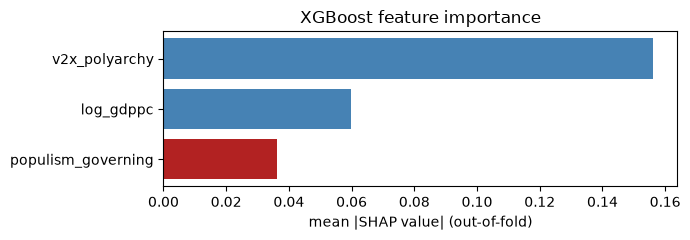

In [13]:
ax = A.shap_importance_plot(xgb)
plt.tight_layout(); plt.show()

**Reading it (corrected framing).** XGBoost uses **raw** features, so it predicts corruption partly from
*between*-country differences (rich, democratic countries are cleaner) that fixed effects remove. It is a
**separate predictive exercise about cross-country prediction — it does not test the within-country
coefficient** and is not an independent confirmation of the FE result (audit #9). What it *does* show is
descriptive: of the three predictors, `populism_governing` contributes the **least** to predicting
corruption (lowest mean |SHAP|); democracy and GDP dominate. Useful context, not proof of the FE finding.

## Section 8 — Robustness: does the conclusion survive alternative choices?

We do **not** pick a "best" model by fit — for an inferential question that would select the
*confounded* answer (pooled OLS fits best but conflates between- and within-country variation). Instead
we run a **robustness ensemble**: re-estimate the same M2 association under different standard-error
estimators and a different way of removing country effects, and ask whether the conclusion is stable.

- **Standard-error variants** (cluster-by-country, two-way cluster, Driscoll–Kraay). These change only
  the *confidence interval*, never the point estimate — a built-in check that our inference does not
  hinge on one SE choice. Driscoll–Kraay additionally corrects for *cross-sectional dependence*
  (regional/global corruption waves).
- **First-difference estimator** removes country effects by *differencing* (Δcorruption ~ Δpopulism)
  instead of demeaning — an independent identification route. If it agrees, the within-null is not an
  artefact of how we stripped the fixed effects.

In [14]:
rob = A.fit_twfe_robustness(panel)
A.robustness_table(rob).round(4)

,estimator,populism_coef,std_err,ci_low,ci_high,p_value
0,TWFE — cluster by country,-0.0715,0.0353,-0.1408,-0.0023,0.0428
1,TWFE — two-way cluster (country & year),-0.0715,0.0348,-0.1398,-0.0033,0.0399
2,TWFE — Driscoll–Kraay (HAC),-0.0715,0.0152,-0.1013,-0.0418,0.0000
3,First-difference (country effects differenced ...,-0.0243,0.0187,-0.0610,0.0124,0.1950


**Reading it.** All three SE variants return the **same** point estimate (−0.072) — only the interval
width changes, exactly as expected. The coefficient is **robustly ≤ 0 and never positive**: the
hypothesised "populism raises corruption" sign does not appear under any specification. How *significant*
the small negative is depends on the choice — marginal under clustering (p≈0.04), clearly non-zero under
Driscoll–Kraay (tighter SEs), and **null under first-differencing** (−0.024, p≈0.20). So the honest,
robust statement is: *within countries there is no positive populism→corruption association; if anything
a weak negative one, but its magnitude is small and not robustly distinguishable from zero.* The headline
— the naive positive correlation does not survive the within-country test — holds across all of them.

In [15]:
# Nested-CV hyperparameter search (inner GroupKFold tunes, outer scores held-out countries).
tuned = A.tune_xgboost_nested_cv(panel)
print(f"tuned XGBoost OOF-R2 = {tuned['tuned_oof_r2_mean']:.3f} +/- {tuned['tuned_oof_r2_std']:.3f}"
      f"   (untuned was ~0.45)")
print("best params (every fold):", tuned['best_params_per_fold'][0])
print("SHAP under the TUNED models:", {k: round(v,4) for k,v in tuned['feature_importances'].items()})

tuned XGBoost OOF-R2 = 0.509 +/- 0.052   (untuned was ~0.45)
best params (every fold): {'learning_rate': 0.03, 'max_depth': 2, 'n_estimators': 200}
SHAP under the TUNED models: {'populism_governing': 0.0158, 'log_gdppc': 0.0508, 'v2x_polyarchy': 0.1525}


**On tuning the predictive check.** Proper nested CV (tuning never sees the held-out countries) moves
out-of-fold R² up only modestly and picks the most-regularised, shallowest model. **SHAP recomputed under
the tuned models** still ranks `populism_governing` last (audit #9) — so the "populism is the weakest
predictor" statement is now backed by the tuned fit, not just the untuned one. Tuning sharpens the
benchmark; it does not change the picture.

### Aggregation & control-set robustness (audit #4, #5)

Two substantive choices could drive the result, so we test both — reproducibly, from the raw data
(`association.sensitivity`). **(a)** Does it depend on representing the government by the *prime
minister's party alone*? We re-estimate with the whole coalition (vote-weighted) and the whole
parliament (seat-share-weighted). **(b)** Does it survive the *originally-specified* controls (rule of
law + regime type) instead of polyarchy? — bearing in mind those may be *post-treatment* (populist
governments can themselves erode rule of law), so conditioning on them can over-control.

In [16]:
from association import sensitivity as S
DB = "../data/duckdb/vdem.duckdb"

def _coef_table(fitted, label):
    rows=[]
    for name, m in fitted.items():
        pred=[x for x in m.params.index if "populism" in x][0]
        ci=m.conf_int().loc[pred]
        rows.append({label:name,"coef":round(float(m.params[pred]),4),
                     "95% CI":f"[{ci['lower']:.3f}, {ci['upper']:.3f}]","p":round(float(m.pvalues[pred]),3)})
    return pd.DataFrame(rows)

print("(a) Alternative populism aggregations:")
display(_coef_table(S.fit_aggregation_robustness(panel, db_path=DB), "aggregation"))
print("(b) Alternative control sets:")
_coef_table(S.fit_control_set_robustness(panel, db_path=DB), "control set")

(a) Alternative populism aggregations:


,aggregation,coef,95% CI,p
0,Senior governing party (baseline),-0.0715,"[-0.141, -0.002]",0.043
1,"All government parties (coalition, vote-wtd)",-0.0567,"[-0.126, 0.013]",0.110
2,All parties (seat-share-wtd),-0.0832,"[-0.214, 0.047]",0.212


(b) Alternative control sets:


,control set,coef,95% CI,p
0,Minimal (GDP only),-0.0715,"[-0.141, -0.002]",0.043
1,Implemented (GDP + polyarchy),-0.0638,"[-0.123, -0.004]",0.036
2,Original design (GDP + rule + regime),-0.0265,"[-0.073, 0.019]",0.258


**Reading it (important).** The **sign stays negative** across every aggregation and control set — the
hypothesised *positive* association never appears. But **significance is fragile**:

- *Aggregation:* significant for the senior-governing-party measure, but not for the coalition
  (vote-weighted, p≈0.11) or parliament (seat-share-weighted, p≈0.21). Two caveats: (i) those weighted
  means **fall back to an unweighted mean** when a weight is missing — in **22.6%** of coalition groups and
  **5.2%** of parliamentary groups, so they are not always truly weighted; (ii) the parliamentary measure
  includes opposition parties, so it estimates a **different thing** (the parliamentary climate), and its
  null is best read as "a different definition shows no effect," not as the governing-party effect failing.
- *Controls:* adding the original-design rule-of-law + regime-type roughly halves the coefficient and it
  loses significance (p≈0.26). This is **consistent with over-controlling** (rule of law and regime type
  are plausibly affected by populist government, i.e. post-treatment) — but collinearity or a genuinely
  different conditional association could also explain it; we do not claim to have demonstrated which.

Honest takeaway: *consistently negative sign, never positive, but significance is specification-dependent.*

## Section 9 — Findings (and clues for Task 4)

*Scope: this is the association (Task 3). Direction (Task 4) and per-sphere decomposition (Task 5) are
separate teammates' work, deliberately out of scope.*

**Headline (corrected).** The naive cross-country correlation is **positive** (+0.14 pooled, matching the
EDA), but with **dependence-adjusted standard errors that cross-country association is *not* statistically
significant** (pooled p≈0.09, between p≈0.13) — the positive is a point estimate, not a precise effect, so
we avoid "entirely between." Within countries, with country + year fixed effects,
governing-party populism has a **small, consistently *negative* contemporaneous association** with
corruption (≈ −0.06 to −0.07). Its significance is **specification-dependent**: not significant in M1 or
under first-differencing, but **significant in the controlled static models M2 and M3** (p ≈ 0.043, 0.036)
and under Driscoll–Kraay SEs. **But significance is fragile**: it fades when populism is aggregated over
the whole coalition or parliament (p ≈ 0.11 / 0.21) and when the originally-specified rule-of-law + regime
controls are used instead of polyarchy (p ≈ 0.26; possibly over-controlling, though collinearity or a genuinely different conditional association could also explain it). So the result is *sign-robust*
(always negative, never the hypothesised positive) but **not significance-robust**.

**The association varies with democracy (a significant interaction).** Populism's marginal effect is
a model-implied **−0.16 (significant) at low polyarchy levels**, −0.08 at median, and **≈ 0 (not significant) at
high polyarchy**. These are *model-implied slopes at low/median/high polyarchy levels*, not regressions on
subgroups of countries; the implied slope is steepest at low polyarchy and fades to ≈0 at high polyarchy.

**Magnitude.** Even where significant it is **small**: a within-country SD move in populism shifts
corruption by ≈ 3% of the *overall* corruption SD — or ≈ 10% of the *within-country* corruption SD, the
apter denominator for a within estimator; a typical election-to-election change is negligible.

**What this does and does not support.**
- It does **not** support the hypothesised *positive* contemporaneous association ("populists in power are
  more corrupt") at the within-country level.
- If anything the within-country association runs **slightly negative**, steepest at low polyarchy levels.
- We do **not** claim the true effect is exactly zero — power is limited (forward-filled, slow-moving
  predictor; few distinct transitions).
- We make **no causal or temporal claim**: populism and corruption are measured in the *same year*, so
  these models establish only a contemporaneous conditional association. They cannot say corruption
  changes "afterwards", that populism *causes* the change, or that the cross-country gap is "all
  selection". Reverse causation, time-varying confounders, anticipation, and measurement remain possible.

**Clues for Task 4 (direction).** Because everything here is contemporaneous, direction is open. The
sign (negative within, steepest at low polyarchy) and the limited same-year movement motivate the
lead–lag / panel-Granger design: test populism(t)→corruption(t+1,t+2) vs corruption(t)→populism(t+1).

**Caveats / limitations.** Limited power (slow-moving step-function predictor); the negative sign may
partly reflect how corruption is coded in consolidated populist regimes (measurement); `v2x_corr` is
bimodal; results are observational. We use TWFE to estimate a **linear conditional association**, not a
heterogeneous causal treatment effect — so broader continuous-treatment-TWFE weighting concerns are not
the frame here (audit #13).